# Rectified Image Processing for Thermal Landscapes Project
### MakhEP

### NOTE: This is an outdated version - use The _Makhohlola.ipynb script instead
 PB 6/13/22
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

In [6]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# Define inputs
img_dir = Path('/n/davies_lab/Lab/data/products/2020_01-02/MakhEP/raster/thermal/rectifiedimages')
shp_f = Path('./data/in/MakhEP_ExclosurePolygon_AD/Makhohlola_polygon.shp')

# Load shapefile
shp = gpd.read_file(shp_f)

# Set threshold of overlap tolerance btwn images
threshold = 0.25

# Set number of images to consider for final image list 
nimgs = 20

### Step 1: Filter imglist to maximize overlap with polygon treatments

In [2]:
# Make list of images to loop through
img_list = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# img_list = imglist[0:10]

# Initialize list of img geometries
geom_list = []

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Loop through each image
    for f in img_list:

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))


    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'img':img_list, 'geometry':geom_list}, geometry='geometry', crs='EPSG:32736')

    # Use the shapefile to get the area overlap of each of the images and each of the treatments
    for ID, feat in zip(shp.id, shp.geometry.values):
        temp = img_gdf.geometry.apply(feat.intersection)

        # Save absolute area of overlap (not as useful as the percent overlap)
        # img_gdf[f'Area {ID}'] = temp.area

        # Save percent overlap with feature
        img_gdf[f'Area Overlap {ID}'] = temp.area / feat.area

    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Sum'] = img_gdf.filter(like='Area').apply(np.nansum, axis=1)

    # Sort and redindex values in descending order of sum area and then 
    img_gdf.sort_values(by=['Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)

    # Save the top 30
    img_gdf_maxarea = img_gdf.loc[0:(nimgs-1)]

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

### Step 2 - Choose a random set of images that do not overlap with each other

In [11]:
# Output dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
pixel_dict = {'imgf':[], 'boundary_poly':[], 'overlapperc':[],
              'pixels_xr':{1:[], 2:[]}, 'N':{1:[], 2:[]}}

# Shuffle the images so you start on a different one each time
# https://stackoverflow.com/questions/29576430/shuffle-dataframe-rows
img_gdf_shuffle = img_gdf_maxarea.sample(frac=1).reset_index(drop=True)

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, g in zip(img_gdf_shuffle.img.values, img_gdf_shuffle.geometry.values):

        # Load image
        img = rioxr.open_rasterio(i,
                                  parse_coordinates=True,
                                  masked=True)

        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)

        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)

        # Check the image's overlap with all previous images that have been processed thusfar
        poly_gs = gpd.GeoSeries(data=pixel_dict['boundary_poly'], crs='EPSG:32736')
        poly_gs.intersects(g)

        # Get the areas of the intersections
        poly_gs_intersect = poly_gs.intersection(g)
        
        # Get the percentage overlap
        poly_overlapperc = poly_gs_intersect.area/g.area
        
        # If any of these values are >= threshold %, don't run the file
        # But if there's minimal overlap, pass it on 
        overlap_idx = np.any(poly_overlapperc >= threshold)
        
        if not(overlap_idx):

            # Save attributes in dict
            pixel_dict['imgf'].append(i)
            pixel_dict['overlapperc'].append(poly_overlapperc)
            # Save the shapely polygon (note: to get that you have to do .values[0])
            # See: https://github.com/geopandas/geopandas/issues/1353
            pixel_dict['boundary_poly'].append(g)

            # loop through features in shapefile
            for ID, feature in zip(shp.id, shp.geometry.values):
                
                # Make a geodataframe to use below
                clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[g])

                # Get the intersection, and clip your raster with it
                pixels = img_k.rio.clip(clipbox.intersection(feature), drop=True)

                # Store it in the nested dictionary
                pixel_dict['pixels_xr'][ID].append(pixels)

                # Also store number of non-na pixels in each
                n = np.sum(np.isnan(pixels.data.flatten()))
                pixel_dict['N'][ID].append(n)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

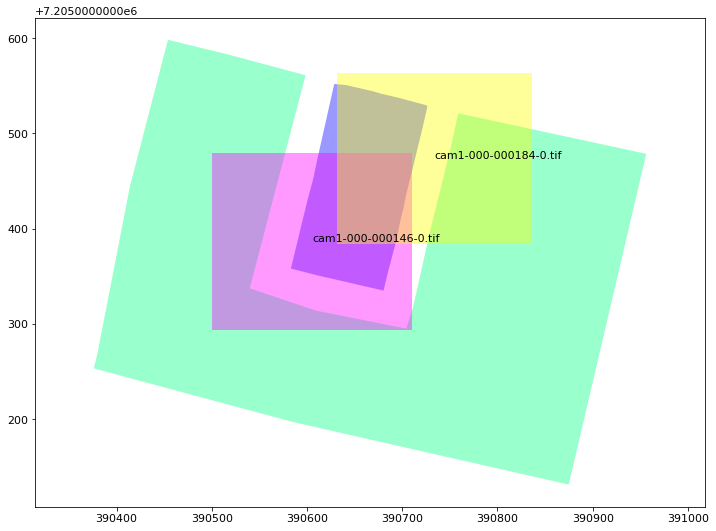

In [12]:
# Plot when done to get a sense of images and locations

# NOTE: need to re-subset polygs with dropflag
poly_gs = gpd.GeoSeries(data=pixel_dict['boundary_poly'], crs='EPSG:32736')

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4)
poly_gs.plot(ax=ax, alpha=0.4, cmap='spring')

labels = [str(s).split('/')[-1] for s in np.array(pixel_dict['imgf'])]

for cx, cy, t in zip(poly_gs.centroid.x.values, poly_gs.centroid.y.values, labels):
    ax.text(cx, cy, t)